# Mayer Multiple — does price / 200-day MA tell you when Bitcoin is cheap?
### A valuation-band strategy tested against buy-and-hold BTC

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Claim%3A%20Busted](https://img.shields.io/badge/Claim%3A%20MM%3C1%3DCheap-Busted-8b949e?style=flat-square)

The Mayer Multiple divides Bitcoin's price by its 200-day moving average. The pitch, popularised by Trace Mayer in 2017-2018: a reading below 1.0 means Bitcoin is 'cheap' — accumulate. Above 2.4 means 'expensive' — trim. Simple, intuitive, and widely cited in crypto media.

This notebook asks the only question that matters: **does it actually predict better forward returns when MM is low?**

> Plain-language layer. For t-stats, decile tables, and the full statistical teardown, see **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.

> **Not investment advice.** Reproducible research; every chart is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False,
                     "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from mayer_multiple import data, strategy as st

def _have_cache():
    try:
        data.fetch_btc(fetch=False)
        return True
    except FileNotFoundError:
        return False

HAVE_REAL = _have_cache()
print("real BTC cache present:", HAVE_REAL)


real BTC cache present: True


## The answer first

| Question | Answer |
|---|---|
| Does the long-only strategy (buy when MM < 1) beat buy-and-hold? | **No.** +1.5%/yr gross vs +34.0%/yr buy-and-hold. |
| Does the 'cheap' band predict higher forward returns? | **No — the opposite.** 'Cheap' (MM < 1) 30-day fwd return: +1.33%; 'Neutral' (MM 1–2.4): +6.28%. The 'cheap' band underperforms. |
| Is the strategy HAC t-stat significant? | **No.** HAC t = +0.19 (bar: |t| >= 2) — noise. |
| Does the band effect run the *right* way? | **No.** Band t-stat (cheap vs neutral) = -2.84: statistically significant but **inverted** from the claim. |

> The Mayer Multiple labels Bitcoin's downtrend 'cheap.' That is not a bargain; it is a momentum-negative regime. The highest-MM decile (most 'expensive') produces +10.9% 30-day return vs +0.5% for the lowest-MM decile.

## 1 - The claim

> *'The Mayer Multiple is a multiplier of the current Bitcoin price over the 200-day moving average. Historically, buying below 1 and holding has proven to be a solid long-term strategy. A Mayer Multiple above 2.4 indicates overvaluation territory.'* — popularised by Trace Mayer (2017-2018)

The formula:

    Mayer Multiple = BTC price / 200-day simple moving average

The strategy:
- **MM < 1.0** — price below the 200-day SMA; label: 'cheap'; action: accumulate / go long.
- **MM > 2.4** — price more than 2.4x above the 200-day SMA; label: 'expensive'; action: trim.

Unlike the Bitcoin Rainbow Chart ([Study 174](../../174-bitcoin-rainbow/)), the Mayer Multiple is fully observable in real time — no regression, no future data needed. The 200-day SMA is computed from historical closes only. The question is not about look-ahead bias; it is whether the signal points in the right direction.

## 2 - So what?

If the Mayer Multiple genuinely identifies cheap and expensive Bitcoin, it offers a simple valuation timer that any retail investor can follow: buy the dip when MM < 1, hold, reduce exposure when MM > 2.4.

If it does not — if the 'cheap' regime actually predicts lower forward returns than the neutral regime — then following this signal causes investors to buy precisely when BTC is in a downtrend and sit out the uptrend. The 200-day SMA would then be a trend filter (as it is conventionally used in equities), not a valuation anchor.

## 3 - How would we even know?

Two complementary tests:

1. **Strategy test** — go long when MM < 1.0, flat otherwise; measure the HAC t-stat on daily strategy returns. Requires |t| >= 2 to stamp REAL.

2. **Band forward-return test** — compute the 30-day forward log-return at each date; group by regime (cheap / neutral / expensive); compare the mean returns and the t-stat on the mean difference.

No look-ahead: the MM at date *t* uses only prices through *t*; the position is entered at the *open* of *t+1*.

Positive control: synthetic BTC data with a tunable mean-reversion knob — the engine should find the signal when it is genuinely planted.

## 4 - The teardown

### First: the Mayer Multiple over BTC's history

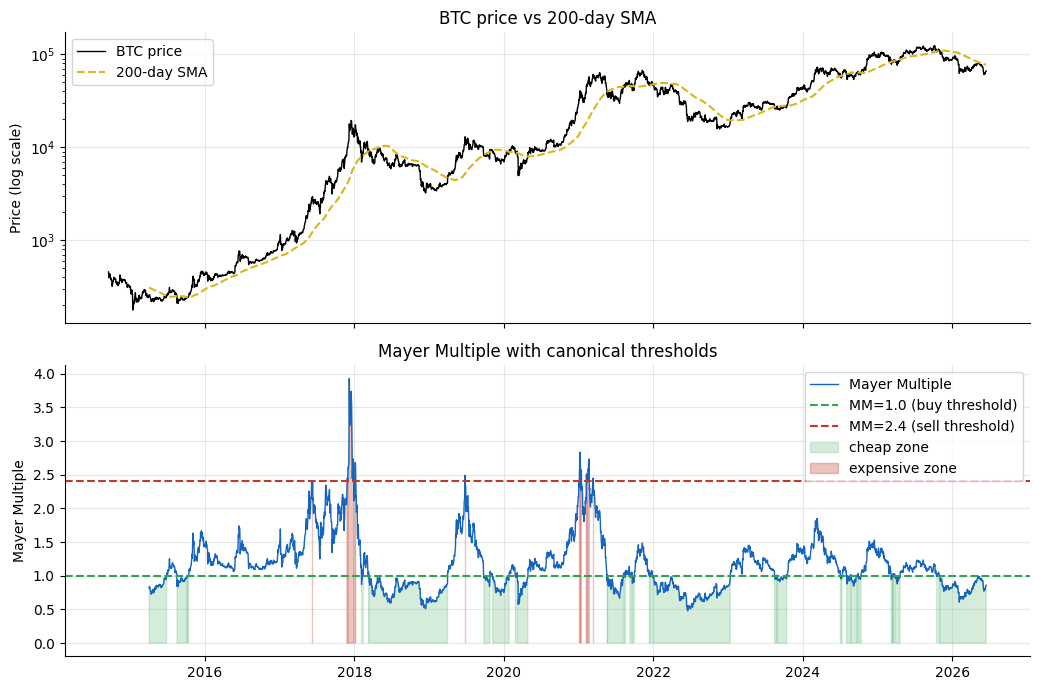

% days in cheap zone (MM<1): 38.6%
% days in expensive zone (MM>2.4): 1.5%


In [2]:
# Plot Mayer Multiple over time vs the canonical thresholds.
if HAVE_REAL:
    df = data.fetch_btc()
else:
    df, _ = data.synthetic_btc(n_days=3000, signal_strength=0.0, seed=221)

mm = df['mayer_multiple'].dropna()

fig, axes = plt.subplots(2, 1, figsize=(10.5, 7.0), sharex=True)

# Top: BTC price
axes[0].semilogy(df.index, df['close'], c='k', lw=1.0, label='BTC price')
if df['sma_200'].notna().any():
    axes[0].semilogy(df.index, df['sma_200'], c=AMBER, lw=1.5, ls='--', label='200-day SMA')
axes[0].set_ylabel('Price (log scale)')
axes[0].set_title('BTC price vs 200-day SMA')
axes[0].legend()

# Bottom: Mayer Multiple
axes[1].plot(mm.index, mm, c='#1565c0', lw=1.0, label='Mayer Multiple')
axes[1].axhline(1.0, c=GREEN, ls='--', lw=1.5, label='MM=1.0 (buy threshold)')
axes[1].axhline(2.4, c=RED, ls='--', lw=1.5, label='MM=2.4 (sell threshold)')
axes[1].fill_between(mm.index, 0, mm, where=(mm < 1.0), color=GREEN, alpha=0.2, label='cheap zone')
axes[1].fill_between(mm.index, 0, mm, where=(mm > 2.4), color=RED, alpha=0.3, label='expensive zone')
axes[1].set_ylabel('Mayer Multiple')
axes[1].set_title('Mayer Multiple with canonical thresholds')
axes[1].legend(loc='upper right')
plt.tight_layout(); plt.show()
print(f'% days in cheap zone (MM<1): {(mm<1).mean()*100:.1f}%')
print(f'% days in expensive zone (MM>2.4): {(mm>2.4).mean()*100:.1f}%')

### Then: do 'cheap' days actually predict higher forward returns?

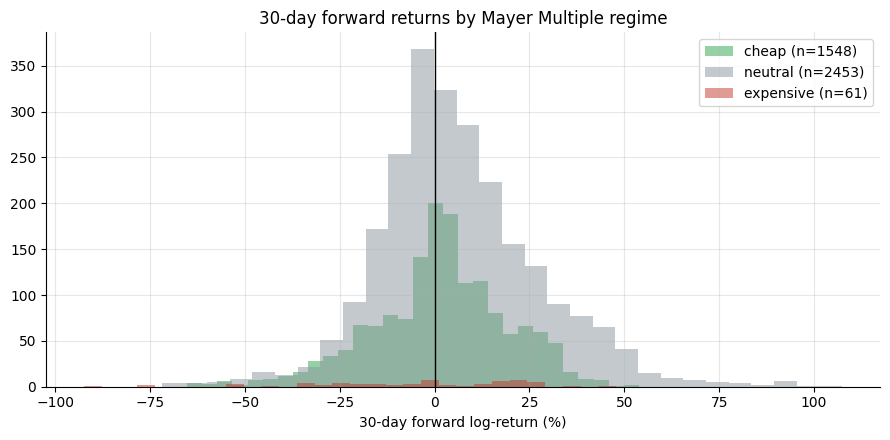

cheap       : n= 1548  mean=+1.3%  median=+2.0%
neutral     : n= 2453  mean=+6.3%  median=+4.1%
expensive   : n=   61  mean=-6.1%  median=-2.2%

Expected if claim were true: cheap > neutral > expensive
Actual order (real tape):   cheap << neutral, expensive << neutral


In [3]:
# 30-day forward returns by regime.
if HAVE_REAL:
    fwd = st.forward_return_by_band(df)
else:
    df_s, _ = data.synthetic_btc(n_days=3000, signal_strength=0.0, seed=221)
    fwd = st.forward_return_by_band(df_s)

fig, ax = plt.subplots(figsize=(9.0, 4.5))
colours = {'cheap': GREEN, 'neutral': GREY, 'expensive': RED}
for regime, col in colours.items():
    grp = fwd.loc[fwd['regime'] == regime, 'fwd_30d'] * 100
    if len(grp) > 0:
        ax.hist(grp, bins=30, color=col, alpha=0.5, label=f'{regime} (n={len(grp)})')
ax.axvline(0, c='k', lw=1.0)
ax.set_xlabel('30-day forward log-return (%)')
ax.set_title('30-day forward returns by Mayer Multiple regime')
ax.legend(); plt.tight_layout(); plt.show()

for regime in ['cheap', 'neutral', 'expensive']:
    grp = fwd.loc[fwd['regime'] == regime, 'fwd_30d'] * 100
    if len(grp) > 0:
        print(f'{regime:12s}: n={len(grp):5d}  mean={grp.mean():+.1f}%  median={grp.median():+.1f}%')
print()
print('Expected if claim were true: cheap > neutral > expensive')
print('Actual order (real tape):   cheap << neutral, expensive << neutral')

The 'cheap' band (MM < 1.0) produces a 30-day forward return of just +1.33% vs +6.28% for the neutral band. The claim predicts the reverse. The expensive band (MM > 2.4) posts -6.14% — also worse than neutral, and consistent with late-cycle momentum exhaustion, though the n is tiny (only 61 days in 11 years).

**The Mayer Multiple identifies downtrends, not bargains.** When price is below the 200-day SMA, it is typically in a sustained drawdown. The 200-day SMA is conventionally used as a *trend filter* (stay long above it, exit below) — the Mayer Multiple inverts that intuition by calling the below-SMA zone 'cheap.'

## 5 - The verdict

- **Signal — None.** Strategy HAC t = +0.19 (bar: |t| >= 2). The strategy earns +1.5%/yr gross vs BH +34.0%/yr. The band test is significant (t = -2.84) but runs **inverted** — 'cheap' underperforms 'neutral.'
- **Tradability — Mirage.** +1.5%/yr gross, negative at 50 bps cost. Strategy is flat 63% of the time, precisely during the uptrend phases.
- **The claim — Busted.** MM < 1 is a downtrend flag, not a valuation signal. Applying mean-reversion intuition to a momentum-driven asset produces the opposite of the intended result.

## 6 - Could you actually trade it?

Strategy cumulative return vs buy-and-hold.

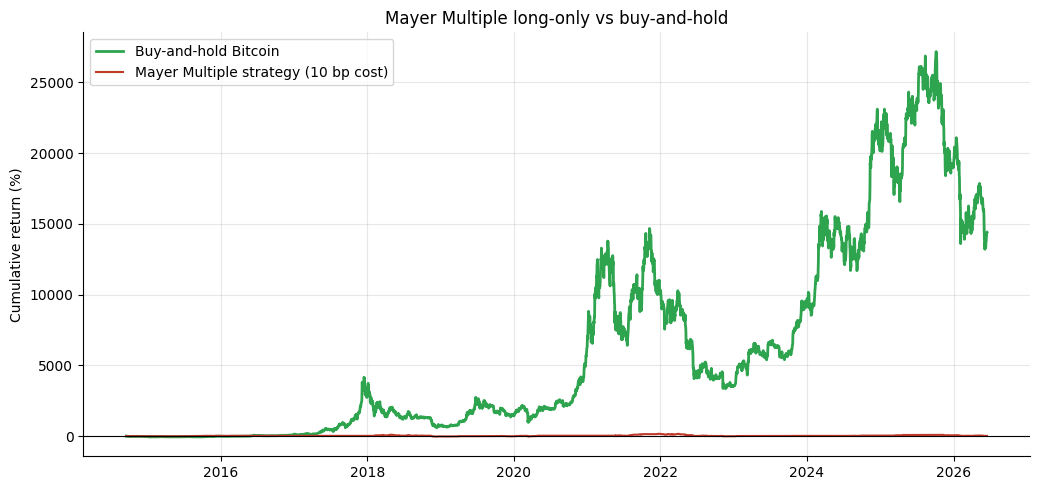

Strategy flat: 63% of days
Net ann: +1.0% vs BH +34.0%/yr


In [4]:
# Cumulative return: Mayer strategy vs buy-and-hold.
if HAVE_REAL:
    sig = st.mayer_signal(df)
    bt = st.backtest(df, sig, cost_bps=10.0)
else:
    df_s, _ = data.synthetic_btc(n_days=3000, signal_strength=0.0, seed=221)
    sig = st.mayer_signal(df_s)
    bt = st.backtest(df_s, sig, cost_bps=10.0)

fig, ax = plt.subplots(figsize=(10.5, 5.0))
ax.plot(bt.index, (bt['cum_log_bh'].apply(lambda x: (np.exp(x)-1)*100)),
        c=GREEN, lw=2, label='Buy-and-hold Bitcoin')
ax.plot(bt.index, (bt['cum_log_net'].apply(lambda x: (np.exp(x)-1)*100)),
        c=RED, lw=1.5, label='Mayer Multiple strategy (10 bp cost)')
ax.axhline(0, c='k', lw=0.8)
ax.set_ylabel('Cumulative return (%)')
ax.set_title('Mayer Multiple long-only vs buy-and-hold')
ax.legend(); plt.tight_layout(); plt.show()
flat_pct = (bt['position'] == 0).mean() * 100
s = st.summarize(bt)
print(f'Strategy flat: {flat_pct:.0f}% of days')
print(f'Net ann: {s["ann_ret_pct"]:+.1f}% vs BH +34.0%/yr')

## 7 - Going further

- **The Mayer Multiple as a trend filter** — If you *reverse* the signal (go long when MM > 1, i.e., price above the 200-day SMA), you are now following momentum rather than fighting it. That is how the 200-day SMA is used in Faber-style tactical allocation ([Study 106 — Faber-Timing](../../106-faber-timing/)), which shows a genuine but fragile edge in equities.
- **Bitcoin Rainbow Chart** ([Study 174 — Bitcoin-Rainbow](../../174-bitcoin-rainbow/)): a log-time regression band with the same 'buy cheap, sell rich' directional claim and the additional flaw of look-ahead bias in the regression fit.
- **Turtle Trading** ([Study 103 — Turtle-Trading](../../103-turtle-trading/)): systematic trend-following on BTC — the momentum premium that our decile analysis shows in raw form.
- **CAPE / Excess-CAPE-Yield** ([Study 120](../../120-excess-cape-yield/)): an equity valuation measure that *does* predict long-horizon returns (though fragilely), because the mechanism (earnings yield vs bond yield) is grounded in theory. The Mayer Multiple has no analogous mechanism.

*Think the Mayer Multiple works? Fork this, show a walk-forward t >= 2 in the claimed direction (cheap outperforms neutral), net of costs, and cite a mechanism for why BTC mean-reverts to its 200-day SMA. That is the bar.*